# Setup

In [1]:
import scipy.io
import pandas as pd
import numpy as np
import cobra
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import mygene
mg = mygene.MyGeneInfo()

plt.rc('font', size=20)

## K-mean clustering for lactate fluxes and pyruvate fluxes

In [4]:
file_path = 'Glycolysis_Pathway_activity_for_four_cell_types.xlsx'
df = pd.read_excel(file_path, sheet_name='Healthy')
# df = df.set_index('Reaction_id')
df

,HXK,GAPDH
0,0,1
1,1,8
2,0,1
3,0,6
4,0,12
...,...,...
1858,0,1
1859,0,2
1860,0,2
1861,0,2


In [7]:
A = df['HXK']
B = df['GAPDH']

# Combine columns A and B into one matrix
combined_matrix = np.column_stack((A, B))

/Users/huahualiu/anaconda3/envs/huahualiu/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


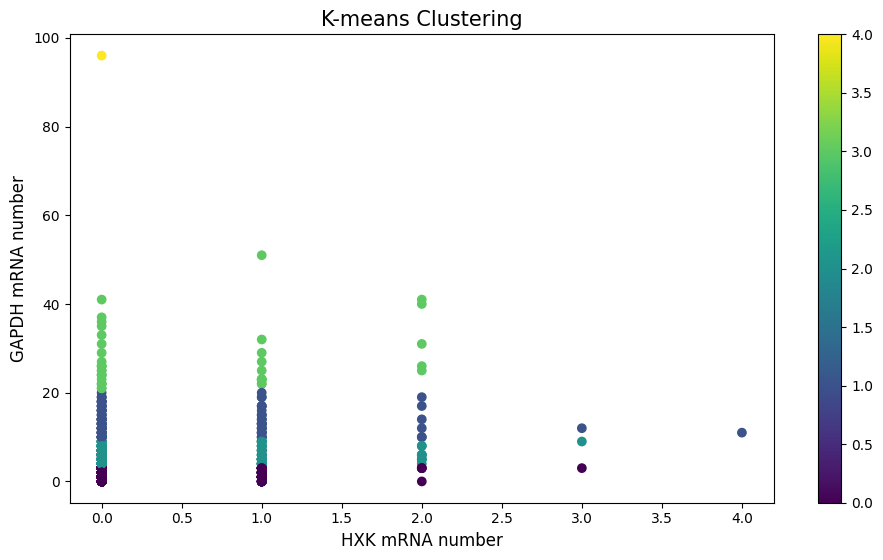

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
plt.figure(figsize=(10, 6))
# Generate random matrix data
# mat_data = scipy.io.loadmat('lactate_with_pyruvate.mat')
# data = mat_data['lactate_fluxes','Pyr_fluxes']
data=combined_matrix 
# Perform K-means clustering
kmeans = KMeans(n_clusters=5)
labels = kmeans.fit_predict(data)

# Plot the clustered data
scatter=plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.title('K-means Clustering',fontsize=15)
plt.xlabel('HXK mRNA number',fontsize=12)
plt.ylabel('GAPDH mRNA number',fontsize=12)

plt.colorbar(scatter)

plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10)
# plt.rcParams['legend.fontsize'] = 15
plt.tight_layout()
plt.show()
# plt.savefig('Figures/lactate_pyruvate_clustered_data(n=5)200cells.png',dpi=300)